# Car Price Prediction System

## Projenin Amacı:
Bu projenin amacı, araçlara ait bazı temel özellikleri kullanarak araba fiyatlarını tahmin eden bir makine öğrenmesi modeli geliştirmektir.

## Neden regresyon problemi?
Bu problem bir regresyon problemidir çünkü hedef değişkenimiz olan **fiyat**, sayısal ve sürekli bir değerdir. Model, araç özellikleri ile fiyat arasındaki ilişkiyi öğrenerek yeni bir araç için tahmini fiyat üretecektir.

## Kapsanan Tensorflow konuları:
- Veriyi hazırlamak
- Train / Test ayırmak
- Model oluşturmak
- Modeli eğitmek
- Model değerlendirmesi yapmak
- Tahmin üretmek

## 2- Veriyi Hazırlama (Numpy/Pandas)

In [26]:
import pandas as pd
import numpy as np

#sentetik araba verisi oluştur
s_size = 600 #veri sayısı
current_year = 2026

#sentetik araba verileri- model yılı, kilometre, motor hacmi, beygir gücü, araç yaşı
#target -> arac fiyatı

model_year = np.random.randint(2008, 2020, s_size) #(min, max, size)
kilometers = np.random.randint(23000, 134000, s_size)
engine_size = np.round(np.random.uniform(1.2, 4.0, s_size),1) #1.2-4 arası rastgele sayı üretir, 1 ondalık basamaga yuvarlar
horsepower = np.random.randint(100, 250, s_size)
car_age = current_year - model_year

#Target (hedef) -> fiyat
#model yılı arttıkca fiyat artar, kilometre arttıkca fiyat düşer, motor hacmi arttıkca fiyat artar
# beygir gücü arttıkca fiyat artar, araç yaşı arttıkça fiyat düşer
price = (
    model_year * 1500
    - kilometers * 0.05
    + engine_size * 20000
    + horsepower * 250
    - car_age * 1800
    + np.random.normal(0, 20000, s_size) #gürültü ekler (mean, std, size)
    
)
                      

#DataFrame
car_data = pd.DataFrame({
    "model_year" : model_year,
    "kilometers": kilometers,
    "engine_size": engine_size,
    "horsepower": horsepower,
    "car_age": car_age,
    "price": price
    
})

car_data.head(10) #ilk 10 satır

#Feature ve Target ayıralım
X = car_data[["model_year", "kilometers","engine_size","horsepower","car_age"]]
y = car_data["price"]

print("X shape: ", X.shape)
print("y shape: ", y.shape)

#normalizasyon (min-max scaling)
# Target normalizasyonu
y = y / 1_000_000
X_normalize = (X-X.min()) / (X.max()-X.min())
X_normalize.head()

X shape:  (600, 5)
y shape:  (600,)


,model_year,kilometers,engine_size,horsepower,car_age
0,0.545455,0.045524,0.892857,0.302013,0.454545
1,0.545455,0.207600,0.392857,0.147651,0.454545
2,1.000000,0.787303,0.678571,0.248322,0.000000
3,1.000000,0.312081,0.071429,0.825503,0.000000
4,0.727273,0.310881,0.821429,0.986577,0.272727


## 3- Train-Test

In [27]:
# %80 train, %20 test olarak ayrılacak
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_normalize, y, test_size=0.2, random_state=42)

print(f"Train data: {X_train.shape}")
print(f"Test data: {X_test.shape}")

Train data: (480, 5)
Test data: (120, 5)


In [28]:
X_train.head()

,model_year,kilometers,engine_size,horsepower,car_age
145,0.272727,0.545438,0.678571,0.879195,0.727273
9,0.545455,0.851565,0.464286,0.181208,0.454545
375,0.454545,0.450971,0.571429,0.221477,0.545455
523,0.909091,0.378156,0.607143,0.590604,0.090909
188,0.636364,0.875626,0.785714,0.785235,0.363636


In [29]:
X_test.head()

,model_year,kilometers,engine_size,horsepower,car_age
110,0.000000,0.232247,0.500000,0.818792,1.000000
419,0.181818,0.883060,0.214286,0.127517,0.818182
565,0.545455,0.122083,0.857143,0.610738,0.454545
77,0.727273,0.671120,0.642857,0.496644,0.272727
181,0.181818,0.302906,1.000000,0.154362,0.818182


## 4-Model oluşturma

In [30]:
#Sequential model
#en az 2 dense hidden layer, 1 output layer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#modeli olusturalım
model = Sequential([
    #64 nöron sayısı, relu da aktivasyon fonku
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)), #input_shape:feature sayısı [1] ise sütundaki 5 feature'ı döndürür
    Dense(32, activation="relu"),
    Dense(1) #regresyon oldugu icin 
])

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 64)                384       
                                                                 
 dense_7 (Dense)             (None, 32)                2080      
                                                                 
 dense_8 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2497 (9.75 KB)
Trainable params: 2497 (9.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 5-Model derleme (Compile)

In [31]:
model.compile(
    optimizer = "adam",
    loss = "mean_squared_error",
    metrics=["mae"]
)

## 6-Training

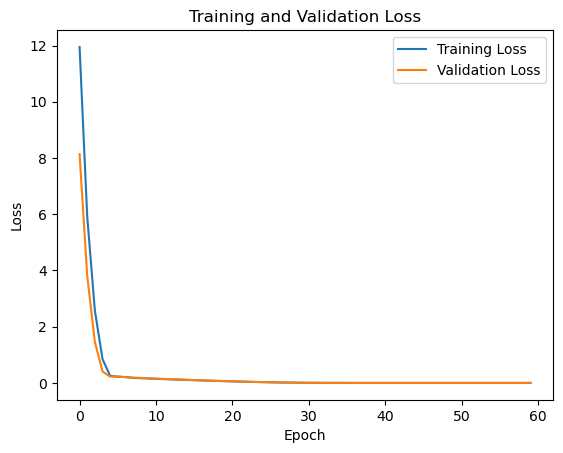

In [32]:
#fit kullan, epoch ve batch size belirle
#validation_split = 0.2 -> train verisinin %20'si eğitim sırasında doğrulama için ayrılır
history = model.fit(X_train, y_train, epochs=60, batch_size=32, validation_split=0.2, verbose=0)

import matplotlib.pyplot as plt
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

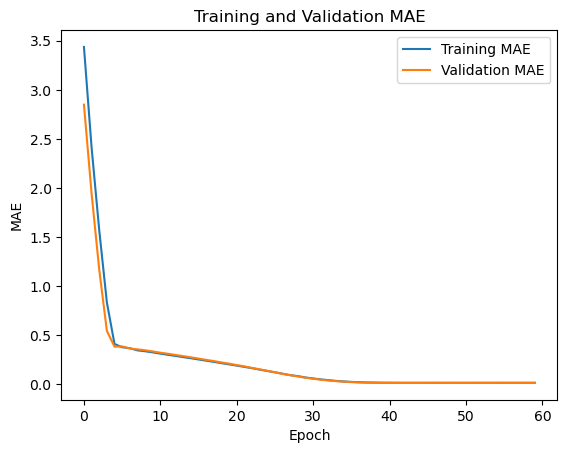

In [33]:
plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training and Validation MAE")
plt.legend()
plt.show()

## 7- Model Değerlendirmesi (Eval)

In [36]:
#test set üzerinde evaluate() 
#MSE ve MAE yorumlama
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f"Test MSE: {test_loss:}")
print(f"Test MAE: {test_mae:}")

## Model Değerlendirmesi
#Model test veri seti üzerinde değerlendirildi.
#Test sonuçları:
# Test MSE değeri 0.000400, Test MAE değeri ise 0.0163 olarak bulunmuştur.
# Price değişkeni milyon ölçeğinde normalize edildiği için bu MAE yaklaşık 16,264 TL ortalama hata anlamına gelir.
# Bu sonuç, modelin test verisi üzerinde oldukça başarılı tahminler yaptığını göstermektedir.
# Training ve validation loss değerleri birbirine yakınsa modelde belirgin bir overfitting olmadığı söylenebilir.

4/4 [==============================] - 0s 4ms/step - loss: 4.0006e-04 - mae: 0.0163
Test MSE: 0.0004000640765298158
Test MAE: 0.016263674944639206


## 8- Model Tahminleri

In [37]:
#yeni bir araç tahmini yap
new_car = pd.DataFrame({
    "model_year" : [2019],
    "kilometers" : [45000],
    "engine_size" : [3.2],
    "horsepower" : [150],
    "car_age" : [current_year-2019]
})

#yeni veriyi normalize edelim
new_car_normalize = (new_car - X.min()) / (X.max() - X.min())

#tahmin yapalım
pricePredict = model.predict(new_car_normalize, verbose=0)
real_price = pricePredict[0][0] * 1_000_000

print(f"Predicted car price:  {real_price:,.2f} TL")
# Model, 2019 model, 45.000 kilometrede, 3.2 motor hacmine ve 150 beygir gücüne sahip bir araç için yaklaşık 3.1 milyon TL fiyat tahmini üretmiştir.
# Bu sonuç, araç özellikleri ile fiyat arasındaki ilişkiyi başarılı şekilde öğrendiğini göstermektedir.

Predicted car price:  3,117,154.12 TL


## 9- Araba Fiyatları Analizi (Yorum)
**Model, araç fiyatlarını tahmin etmek için şu özellikleri kullanmaktadır:**
- Model yılı
- Kilometre
- Motor hacmi
- Beygir gücü
- Araç yaşı

### Hangi feature daha etkili olabilir?
Fiyat formülüne bakıldığında bazı değişkenlerin fiyat üzerinde daha güçlü etkisi olduğu görülmektedir. Özellikle **motor hacmi (engine_size)** ve **beygir gücü (horsepower)** fiyatı önemli ölçüde artırmaktadır. Ayrıca **model yılı** da aracın daha yeni olmasını temsil ettiği için fiyatı artıran önemli bir faktördür. Buna karşılık **kilometre** ve **araç yaşı** arttıkça araç değeri düşmektedir. Bu değişkenler fiyat üzerinde negatif etkiye sahiptir.

### Model hangi araçları daha iyi tahmin eder?

Model, eğitim verisine benzer özelliklere sahip araçları daha iyi tahmin edebilir. Özellikle:

- orta kilometredeki araçlar
- veri setindeki model yılları aralığında bulunan araçlar
- ortalama motor hacmine ve beygir gücüne sahip araçlar

model tarafından daha doğru tahmin edilebilir.


### Model hangi araçlarda zorlanabilir?

Model aşağıdaki durumlarda daha az doğru tahminler yapabilir:

- veri setinde çok az bulunan araç türleri
- çok yüksek kilometreli araçlar
- aşırı yüksek motor hacmine veya beygir gücüne sahip araçlar
- veri setindeki aralıkların dışında kalan yeni veya eski araçlar

**Bu durumlar modelin daha önce görmediği veri dağılımlarına karşı genelleme yapmasını zorlaştırabilir.**

## 10- Yönetici özeti

In [43]:
print("Yönetici Özeti")
print("-------------------------------------------")
print("- Ortalama tahmin hatası: yaklaşık 16.000 TL")
print("- Model ikinci el araç fiyatlarını tahmin edebilir")
print("- Özellikle veri setindeki aralıkta bulunan araçlarda daha başarılıdır")
print("- Daha büyük veri setleri ile performans artırılabilir")

Yönetici Özeti
-------------------------------------------
- Ortalama tahmin hatası: yaklaşık 16.000 TL
- Model ikinci el araç fiyatlarını tahmin edebilir
- Özellikle veri setindeki aralıkta bulunan araçlarda daha başarılıdır
- Daha büyük veri setleri ile performans artırılabilir
